# Exploratory Data Analysis — Netiquette & Toxicity Corpora

This notebook provides a structured exploration of the seven annotated corpora used in the thesis
on **multilabel netiquette and online toxicity classification**.

---

| # | Dataset | Language | Domain | Raw Format |
|---|---|---|---|---|
| 1 | Jigsaw Toxic Comment Classification | EN / multilingual | Wikipedia Talk | CSV |
| 2 | Wikipedia Personal Attacks | EN | Wikipedia Talk | CSV |
| 3 | Stanford / Wikipedia Politeness Corpus | EN | Wikipedia Talk | JSONL |
| 4 | Wikipedia Detox | EN | Wikipedia Talk | TSV |
| 5 | gutefrage.net Moderation Dataset | DE | Q&A platform | Apple Numbers |
| 6 | GMHP7k — German Misogynistic Hate Speech | DE | Twitter / Social media | CSV |
| 7 | HOCON34k — German Newspaper Comments | DE | Online newspapers | CSV |

---

**Sections**
1. Dataset Loading — shape, columns, dtypes, sample rows
2. Missing Values — null texts, label coverage per corpus
3. Label Distribution — positive vs negative counts, class imbalance
4. Text Length — word-count distributions
5. Multilabel Co-occurrence — label correlation heatmaps
6. Summary Comparison — cross-dataset statistics table

In [5]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent          # notebooks/ → project root
DATA_DIR     = PROJECT_ROOT / 'data' / 'raw'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT))

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.facecolor':  'white',
})
sns.set_theme(style='whitegrid', palette='muted')

# 7 distinct colours — one per corpus
COLORS = [
    '#e05c5c',  # Jigsaw
    '#e0963c',  # WP Attacks
    '#5c9ce0',  # WP Polite
    '#8c5ce0',  # WP Detox
    '#5cbf7c',  # gutefrage
    '#e05ca0',  # GMHP7k
    '#c8b400',  # HOCON34k
]

SHORT = {
    'Jigsaw Toxic Comments':       'Jigsaw',
    'Wikipedia Personal Attacks':  'WP Attacks',
    'Wikipedia Politeness':        'WP Polite',
    'Wikipedia Detox':             'WP Detox',
    'gutefrage.net':               'gutefrage',
    'GMHP7k':                      'GMHP7k',
    'HOCON34k':                    'HOCON34k',
}

print('Setup complete.')
print(f'Data directory : {DATA_DIR}')
print(f'Exists         : {DATA_DIR.exists()}')

Setup complete.
Data directory : /Users/anhdang/PycharmProjects/netiquette-multilabel-classification/data/raw
Exists         : True


---
## 1. Dataset Loading

Each corpus is loaded through the project's unified loader pipeline which handles raw format
differences (CSV, TSV, JSONL, Apple Numbers) and normalises output into a consistent schema:

```
text | source | language | split | hate_speech | misogyny | toxic | severe_toxic
     | obscene | threat | insult | identity_hate | attack | impolite
```

Labels not annotated by a corpus are stored as `NaN`. This design enables **multi-task learning**
where the loss function is computed only over the labels each corpus actually provides.

> **Note on raw formats:** The Wikipedia Politeness corpus is distributed as JSONL; the
> gutefrage.net dataset is an Apple Numbers spreadsheet. Both are handled transparently
> by their respective loaders.

In [6]:
from src.dataset.loaders import (
    JigsawLoader,
    WikipediaAttacksLoader,
    WikipediaPolitenessLoader,
    DetoxLoader,
    GutefragLoader,
    GMHP7kLoader,
    HOCON34kLoader,
)
from src.dataset.schema import ALL_LABELS, CORPUS_LABELS

SOURCE_KEY = {
    'Jigsaw Toxic Comments':       'jigsaw',
    'Wikipedia Personal Attacks':  'wikipedia_attacks',
    'Wikipedia Politeness':        'wikipedia_politeness',
    'Wikipedia Detox':             'detox',
    'gutefrage.net':               'gutefrage',
    'GMHP7k':                      'gmhp7k',
    'HOCON34k':                    'hocon34k',
}

LOADER_MAP = {
    'Jigsaw Toxic Comments':       JigsawLoader(),
    'Wikipedia Personal Attacks':  WikipediaAttacksLoader(),
    'Wikipedia Politeness':        WikipediaPolitenessLoader(),
    'Wikipedia Detox':             DetoxLoader(),
    'gutefrage.net':               GutefragLoader(),
    'GMHP7k':                      GMHP7kLoader(),
    'HOCON34k':                    HOCON34kLoader(),
}

datasets = {}
for name, loader in LOADER_MAP.items():
    print(f'Loading {name} ...', end='  ')
    df = loader.load(DATA_DIR)
    datasets[name] = df
    print(f'{len(df):,} rows')

total = sum(len(d) for d in datasets.values())
print(f'\nTotal rows across all datasets: {total:,}')

Loading Jigsaw Toxic Comments ...  223,549 rows
Loading Wikipedia Personal Attacks ...  115,864 rows
Loading Wikipedia Politeness ...  4,353 rows
Loading Wikipedia Detox ...  159,686 rows
Loading gutefrage.net ...  19,045 rows
Loading GMHP7k ...  7,207 rows
Loading HOCON34k ...  34,272 rows

Total rows across all datasets: 563,976


In [7]:
SEP = '─' * 65

for name, df in datasets.items():
    src_key = SOURCE_KEY[name]
    labels  = CORPUS_LABELS[src_key]

    print(SEP)
    print(f'  {name}')
    print(SEP)
    print(f'  Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Language   : {df["language"].unique().tolist()}')
    print(f'  Labels     : {labels}')

    split_counts = df['split'].value_counts(dropna=False)
    split_str = ', '.join(f'{k}={v:,}' for k, v in split_counts.items())
    print(f'  Splits     : {split_str}')

    cols = ['text', 'source', 'language', 'split'] + labels
    print()
    print('  dtypes:')
    display(df[cols].dtypes.to_frame('dtype').T)

    print('  Sample rows (text truncated to 80 chars):')
    sample = df[cols].head(3).copy()
    sample['text'] = sample['text'].str[:80] + '...'
    display(sample)
    print()

─────────────────────────────────────────────────────────────────
  Jigsaw Toxic Comments
─────────────────────────────────────────────────────────────────
  Shape      : 223,549 rows x 14 columns
  Language   : ['multilingual']
  Labels     : ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
  Splits     : train=159,571, test=63,978

  dtypes:


,text,source,language,split,toxic,severe_toxic,obscene,threat,insult,identity_hate
dtype,object,object,object,object,float64,float64,float64,float64,float64,float64


  Sample rows (text truncated to 80 chars):


,text,source,language,split,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,jigsaw,multilingual,train,0.0,0.0,0.0,0.0,0.0,0.0
1,D'aww! He matches this background colour I'm s...,jigsaw,multilingual,train,0.0,0.0,0.0,0.0,0.0,0.0
2,"Hey man, I'm really not trying to edit war. It...",jigsaw,multilingual,train,0.0,0.0,0.0,0.0,0.0,0.0



─────────────────────────────────────────────────────────────────
  Wikipedia Personal Attacks
─────────────────────────────────────────────────────────────────
  Shape      : 115,864 rows x 14 columns
  Language   : ['en']
  Labels     : ['attack']
  Splits     : train=69,526, test=23,178, dev=23,160

  dtypes:


...

,text,source,language,split,hate_speech,misogyny
0,@TwitterUser Ich habe wenig Erfahrung mit Lesb...,gmhp7k,de,NaN,1.0,1.0
1,@TwitterUser Geh scheissen...,gmhp7k,de,NaN,0.0,0.0
2,@TwitterUser Baerziege wäre richtig gegendert....,gmhp7k,de,NaN,1.0,1.0



─────────────────────────────────────────────────────────────────
  HOCON34k
─────────────────────────────────────────────────────────────────
  Shape      : 34,272 rows x 14 columns
  Language   : ['de']
  Labels     : ['hate_speech']
  Splits     : train=27,378, test=3,423, val=3,422, None=49

  dtypes:


,text,source,language,split,hate_speech
dtype,object,object,object,object,float64


  Sample rows (text truncated to 80 chars):


,text,source,language,split,hate_speech
0,Mein Motto: Leben und leben lassen ! Aber bei ...,hocon34k,de,None,1.0
1,"Aber nimmer, wenn Du auch dort bist... ...",hocon34k,de,None,0.0
2,Auf meiner Party kriegst auch mal eine ab! Für...,hocon34k,de,None,1.0


---
## 2. Missing Values

Two types of missingness matter here:

- **Null text** — rows without text are unusable and should be zero after the loaders' cleaning
  step (both `body` and `question_title` null for gutefrage; empty JSONL entries for Politeness).
- **Label coverage** — each corpus annotates only a subset of the 10 unified labels; the
  remaining labels are `NaN` by design, *not* an error.

The heatmap below makes the label coverage explicit: **green = annotated, red = not annotated**.

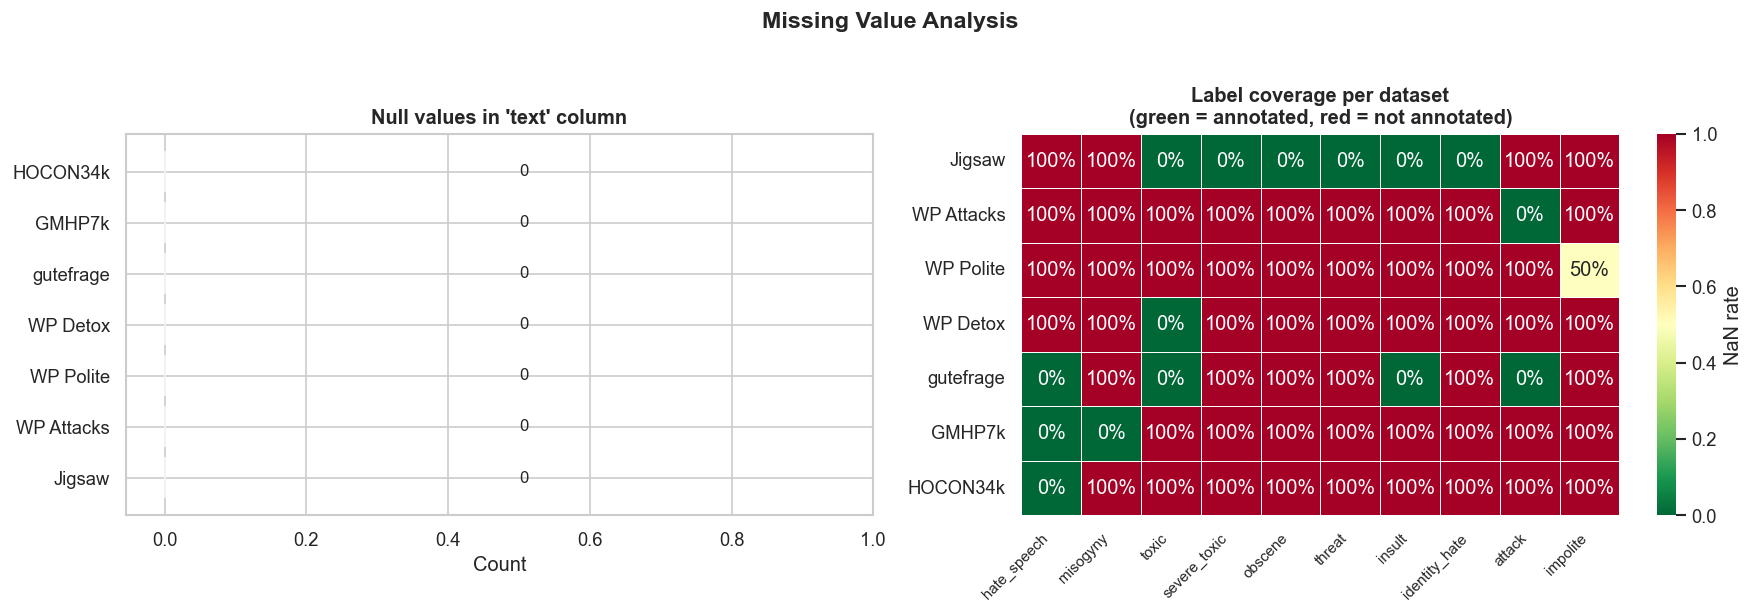

Null text counts:


,null_text_rows
Jigsaw,0
WP Attacks,0
WP Polite,0
WP Detox,0
gutefrage,0
GMHP7k,0
HOCON34k,0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: null text counts per dataset ───────────────────────────────────────
null_counts = pd.Series(
    {SHORT[n]: int(df['text'].isna().sum()) for n, df in datasets.items()}
)
bars = axes[0].barh(
    null_counts.index, null_counts.values,
    color=[COLORS[i] for i in range(len(null_counts))], alpha=0.85
)
axes[0].set_title("Null values in 'text' column", fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_xlim(right=max(null_counts.values) * 1.3 + 1)
for bar, val in zip(bars, null_counts.values):
    axes[0].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', fontsize=10
    )

# ── Right: label NaN coverage heatmap ────────────────────────────────────────
nan_matrix = pd.DataFrame(
    {SHORT[n]: {lbl: float(df[lbl].isna().mean()) for lbl in ALL_LABELS}
     for n, df in datasets.items()}
).T

sns.heatmap(
    nan_matrix,
    ax=axes[1],
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    annot=True, fmt='.0%',
    linewidths=0.5,
    cbar_kws={'label': 'NaN rate'},
)
axes[1].set_title('Label coverage per dataset\n(green = annotated, red = not annotated)',
                  fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_missing_values.png', bbox_inches='tight')
plt.show()

# ── Tabular summary ───────────────────────────────────────────────────────────
print('Null text counts:')
display(null_counts.to_frame('null_text_rows'))

---
## 3. Label Distribution

We examine two complementary views of the label distribution:

1. **Absolute counts** (positive vs negative per label per dataset) — reveals how many
   labelled examples are available for each category.
2. **Positive rate (%)** — quantifies class imbalance. Rates below **10 %** are flagged
   as strongly imbalanced and typically require mitigation strategies during training
   (e.g. class-weighted cross-entropy, focal loss, or oversampling).

Class imbalance is inherent to abuse-detection datasets: the vast majority of user-generated
content is benign.

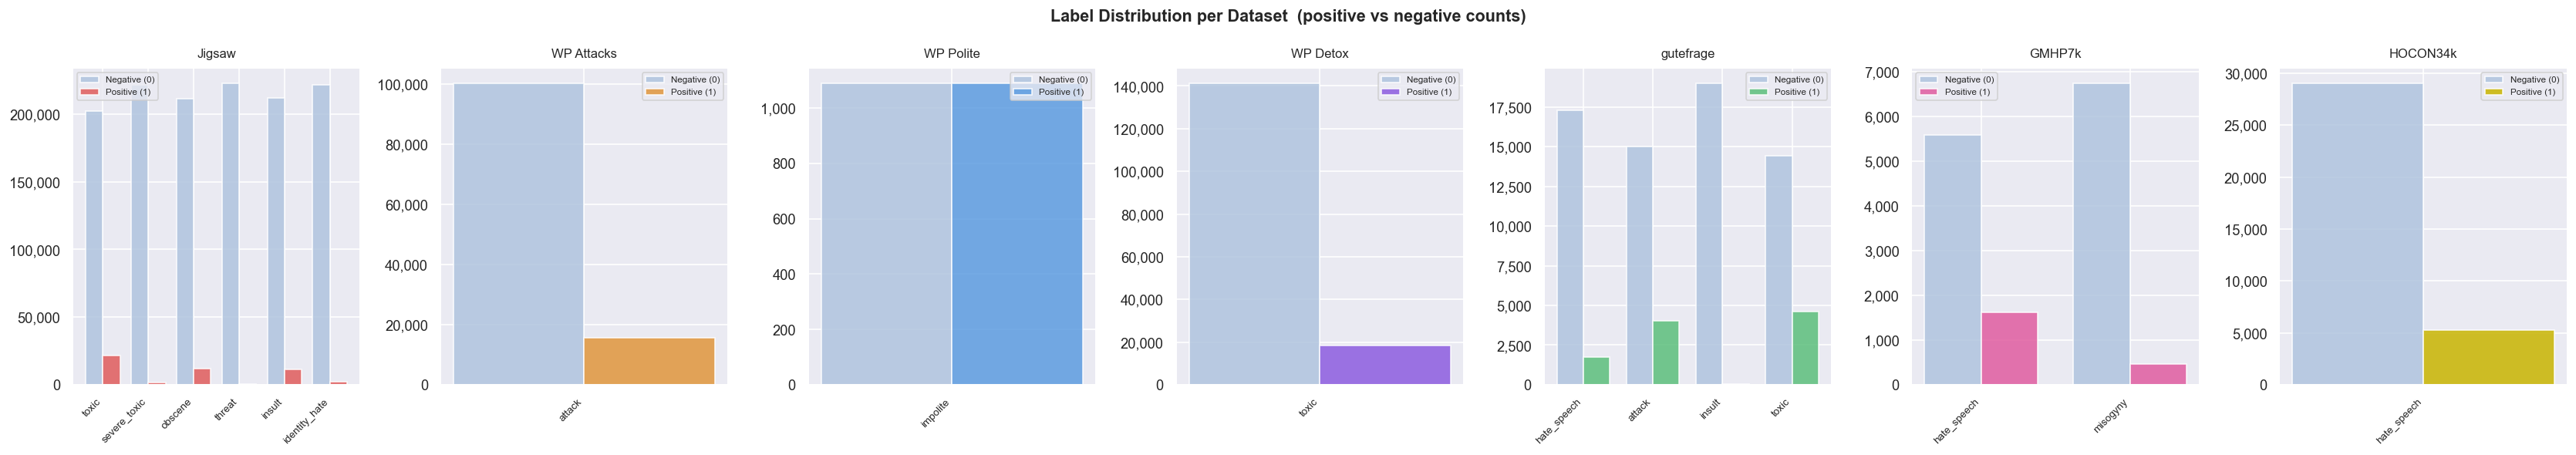

In [10]:
n = len(datasets)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    labels = CORPUS_LABELS[SOURCE_KEY[name]]
    pos    = [(df[lbl] == 1.0).sum() for lbl in labels]
    neg    = [(df[lbl] == 0.0).sum() for lbl in labels]

    x = np.arange(len(labels))
    w = 0.38
    ax.bar(x - w / 2, neg, w, label='Negative (0)', color='#b0c4de', alpha=0.85)
    ax.bar(x + w / 2, pos, w, label='Positive (1)', color=color,    alpha=0.85)

    ax.set_title(SHORT[name], fontsize=10, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{int(v):,}')
    )
    ax.legend(fontsize=7)

plt.suptitle('Label Distribution per Dataset  (positive vs negative counts)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_label_distribution.png', bbox_inches='tight')
plt.show()

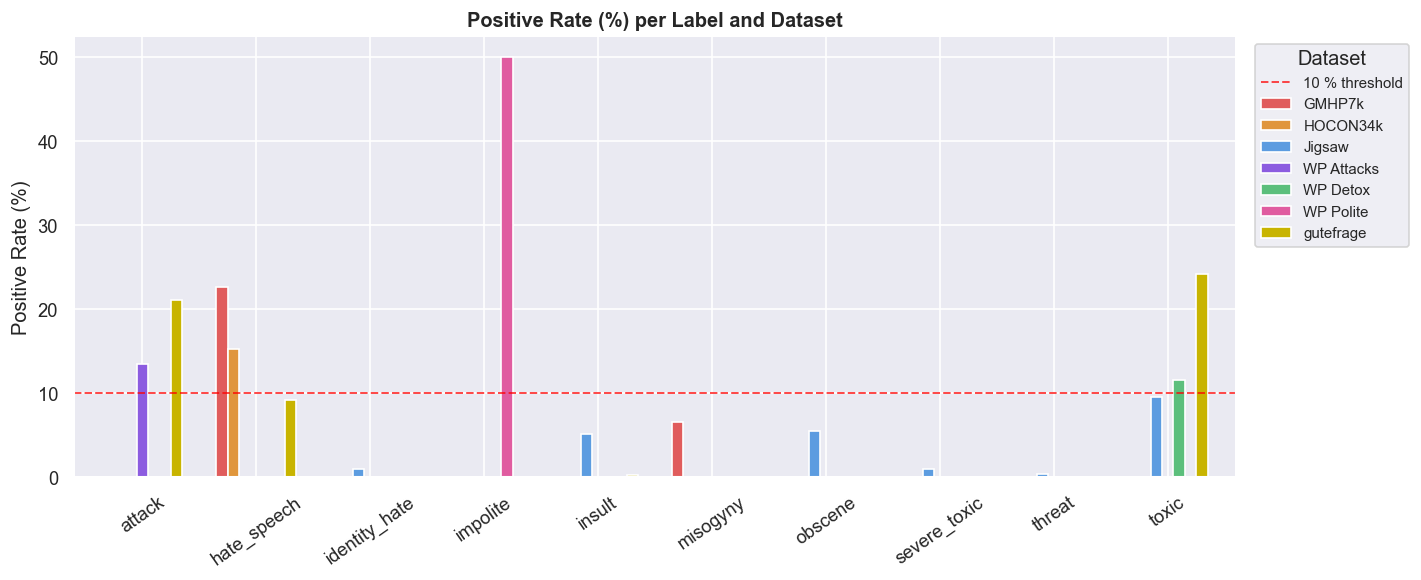

Positive rates table (%):


dataset,GMHP7k,HOCON34k,Jigsaw,WP Attacks,WP Detox,WP Polite,gutefrage
label,,,,,,,
attack,0.0%,0.0%,0.0%,13.4%,0.0%,0.0%,21.1%
hate_speech,22.6%,15.3%,0.0%,0.0%,0.0%,0.0%,9.1%
identity_hate,0.0%,0.0%,0.9%,0.0%,0.0%,0.0%,0.0%
impolite,0.0%,0.0%,0.0%,0.0%,0.0%,50.0%,0.0%
insult,0.0%,0.0%,5.1%,0.0%,0.0%,0.0%,0.3%
misogyny,6.5%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
obscene,0.0%,0.0%,5.4%,0.0%,0.0%,0.0%,0.0%
severe_toxic,0.0%,0.0%,0.9%,0.0%,0.0%,0.0%,0.0%
threat,0.0%,0.0%,0.3%,0.0%,0.0%,0.0%,0.0%


In [12]:
rate_rows = []
for name, df in datasets.items():
    for lbl in CORPUS_LABELS[SOURCE_KEY[name]]:
        total    = int(df[lbl].notna().sum())
        pos_rate = (df[lbl] == 1.0).sum() / total * 100 if total > 0 else 0.0
        rate_rows.append({'dataset': SHORT[name], 'label': lbl, 'pos_%': round(float(pos_rate), 2)})

rate_df = pd.DataFrame(rate_rows)
pivot   = rate_df.pivot(index='label', columns='dataset', values='pos_%').fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot.bar(ax=ax, rot=35, width=0.7, color=COLORS[:len(pivot.columns)])

ax.axhline(y=10, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='10 % threshold')
ax.set_title('Positive Rate (%) per Label and Dataset', fontweight='bold')
ax.set_ylabel('Positive Rate (%)')
ax.set_xlabel('')
ax.legend(title='Dataset', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_positive_rates.png', bbox_inches='tight')
plt.show()

print('Positive rates table (%):')
display(
    pivot.style
    .format('{:.1f}%')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0, vmax=40)
)

---
## 4. Text Length Distribution

Token length directly affects model architecture choices:

- Transformer models (BERT, RoBERTa) cap input at **512 tokens**.
- A truncation length of **128** covers the majority of texts efficiently.
- A truncation length of **256** captures most of the long-tail with moderate padding overhead.

We measure **word count** as a proxy for token count (actual subword tokens will be
slightly higher). Distributions are clipped at the **99th percentile** to suppress outliers
and improve readability.

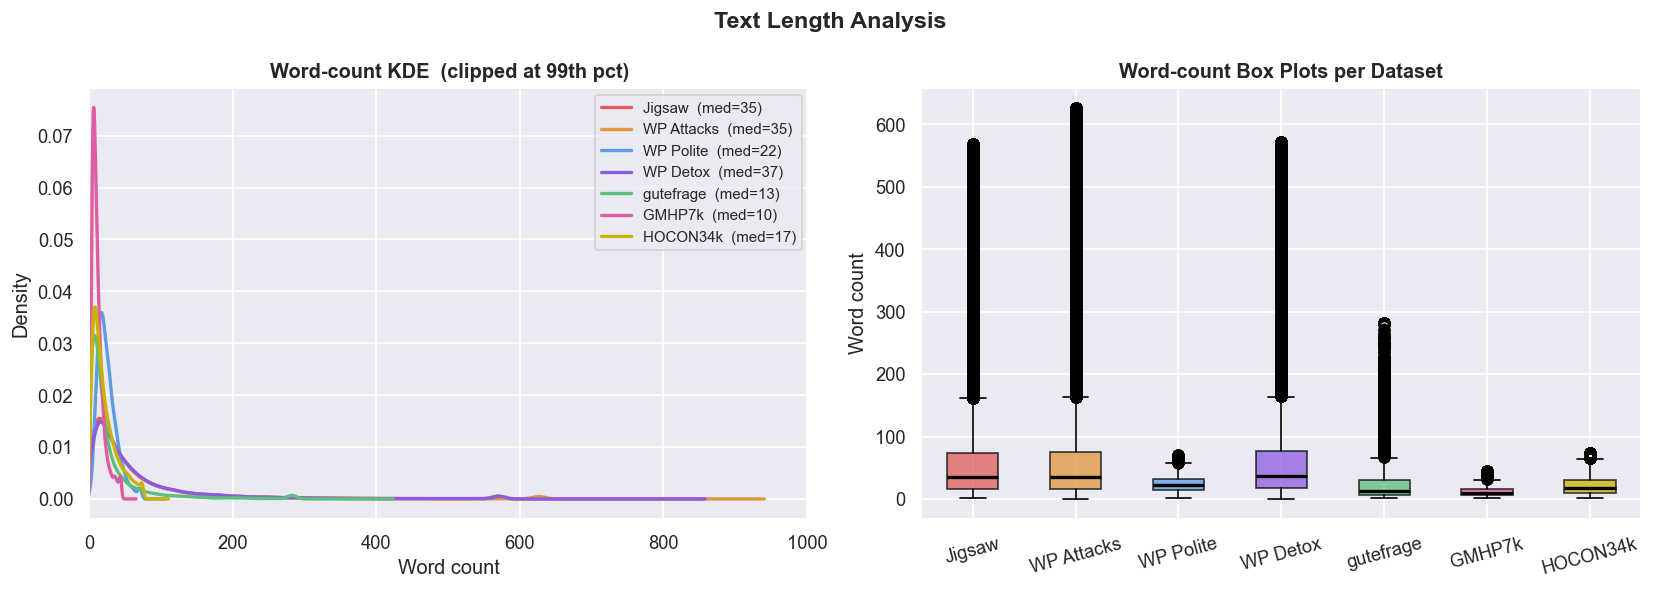

Word-count statistics:


,min,median,mean,p95,p99,max
Jigsaw,1.0,35.0,66.5,227.0,569.0,2321.0
WP Attacks,0.0,35.0,70.2,230.0,627.0,2832.0
WP Polite,1.0,22.0,25.2,51.0,71.0,133.0
WP Detox,0.0,37.0,68.2,232.0,572.0,1411.0
gutefrage,1.0,13.0,30.6,111.0,282.0,2376.0
GMHP7k,1.0,10.0,12.4,33.0,44.0,53.0
HOCON34k,1.0,17.0,22.0,60.0,74.0,94.0


In [13]:
word_counts = {
    name: df['text'].dropna().astype(str).str.split().str.len()
    for name, df in datasets.items()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── KDE ──────────────────────────────────────────────────────────────────────
for (name, wc), color in zip(word_counts.items(), COLORS):
    p99 = wc.quantile(0.99)
    wc.clip(upper=p99).plot.kde(
        ax=axes[0],
        label=f'{SHORT[name]}  (med={int(wc.median())})',
        color=color, linewidth=2
    )
axes[0].set_title('Word-count KDE  (clipped at 99th pct)', fontweight='bold')
axes[0].set_xlabel('Word count')
axes[0].set_xlim(left=0)
axes[0].legend(fontsize=9)

# ── Box plots ─────────────────────────────────────────────────────────────────
box_data   = [wc.clip(upper=wc.quantile(0.99)).values for wc in word_counts.values()]
box_labels = [SHORT[n] for n in word_counts]
bp = axes[1].boxplot(
    box_data, labels=box_labels, patch_artist=True, notch=False,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Word-count Box Plots per Dataset', fontweight='bold')
axes[1].set_ylabel('Word count')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Text Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_text_length.png', bbox_inches='tight')
plt.show()

# ── Stats table ───────────────────────────────────────────────────────────────
stats = pd.DataFrame({
    SHORT[name]: {
        'min':    int(wc.min()),
        'median': int(wc.median()),
        'mean':   round(float(wc.mean()), 1),
        'p95':    int(wc.quantile(0.95)),
        'p99':    int(wc.quantile(0.99)),
        'max':    int(wc.max()),
    }
    for name, wc in word_counts.items()
}).T

print('Word-count statistics:')
display(stats)

---
## 5. Multilabel Co-occurrence

When a dataset provides multiple binary labels, it is important to understand how often they
co-occur. High positive correlation means two labels rarely diverge and may share a common
representation; negative correlation suggests mutual exclusion.

Two views are shown:

1. **Jigsaw** — the richest individual multilabel dataset (6 labels). A lower-triangle
   correlation matrix avoids duplicate information.
2. **Combined** — Pearson correlation across all 10 unified labels, using data from
   all five corpora stacked (NaN values are excluded pairwise).

> *Expected findings:* `toxic`, `insult`, and `obscene` typically correlate strongly in
> Jigsaw; `threat` tends to be more independent. Across corpora, `attack` and `hate_speech`
> may show moderate correlation since both capture adversarial language.

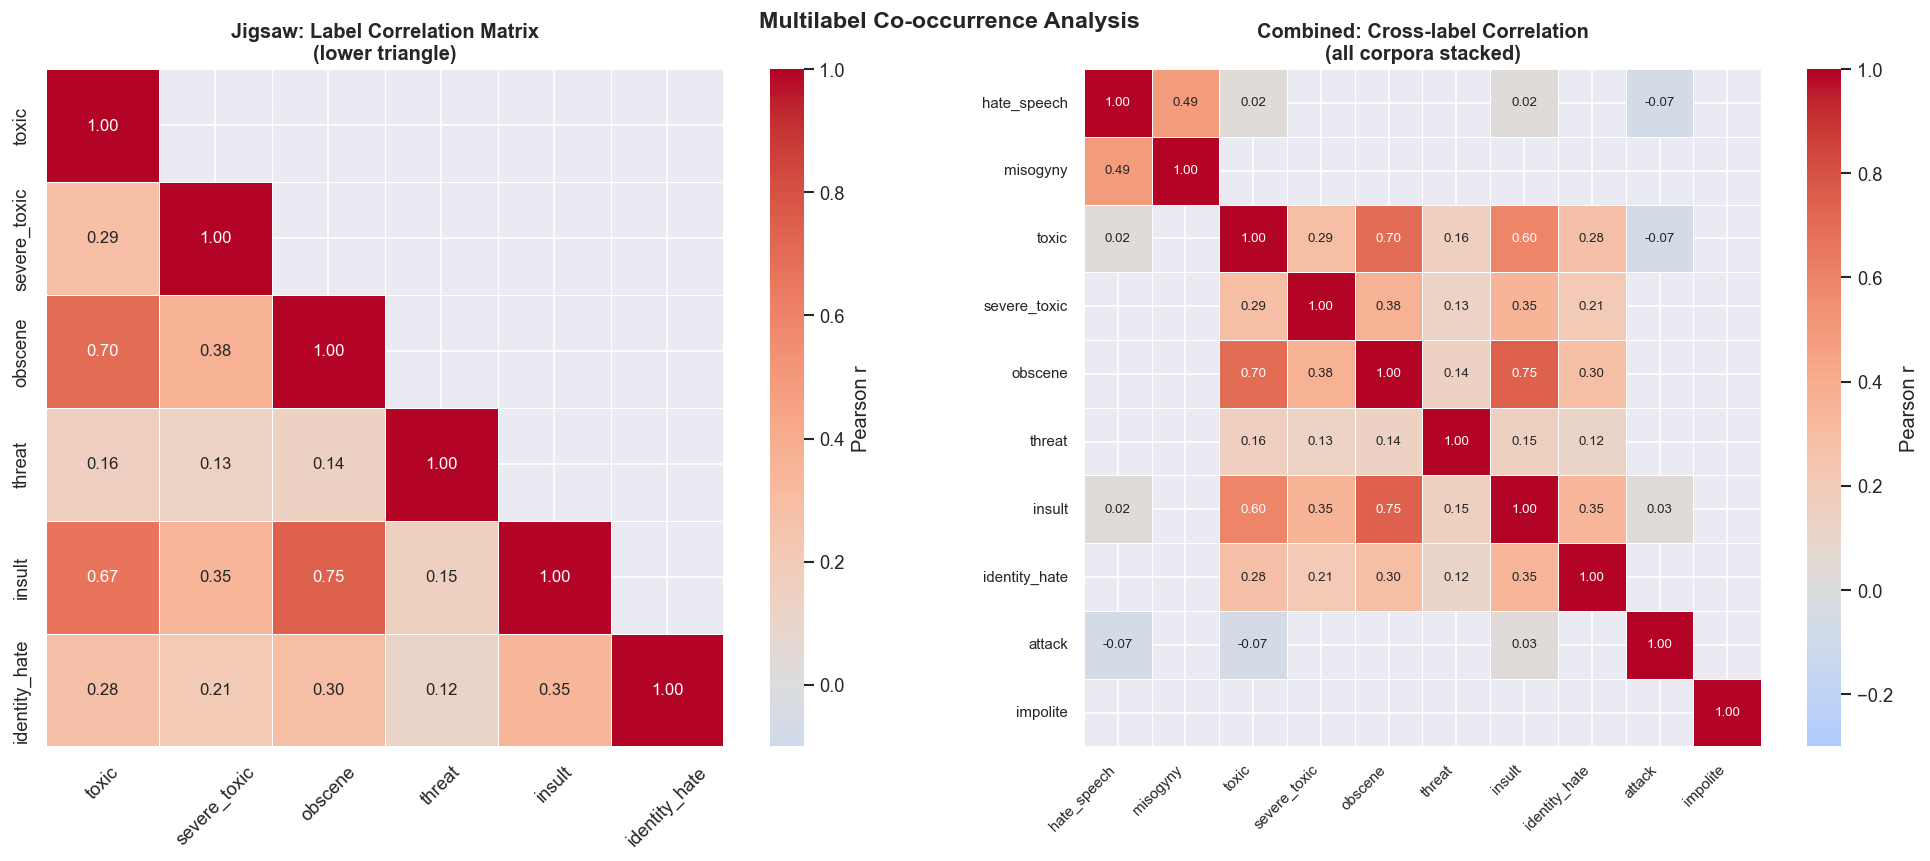

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ── Jigsaw label correlation ──────────────────────────────────────────────────
jigsaw_labels = CORPUS_LABELS['jigsaw']
jigsaw_data   = datasets['Jigsaw Toxic Comments'][jigsaw_labels].dropna()
jigsaw_corr   = jigsaw_data.corr()

mask_upper = np.triu(np.ones_like(jigsaw_corr, dtype=bool), k=1)
sns.heatmap(
    jigsaw_corr, ax=axes[0],
    mask=mask_upper,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-0.1, vmax=1.0,
    linewidths=0.5, square=True,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Pearson r'},
)
axes[0].set_title('Jigsaw: Label Correlation Matrix\n(lower triangle)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# ── Combined cross-dataset label correlation ──────────────────────────────────
all_data      = pd.concat([df[ALL_LABELS] for df in datasets.values()], ignore_index=True)
combined_corr = all_data.corr()

sns.heatmap(
    combined_corr, ax=axes[1],
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-0.3, vmax=1.0,
    linewidths=0.5, square=True,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Pearson r'},
)
axes[1].set_title('Combined: Cross-label Correlation\n(all corpora stacked)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=9)

plt.suptitle('Multilabel Co-occurrence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_cooccurrence.png', bbox_inches='tight')
plt.show()

---
## 6. Dataset Comparison Summary

The table below aggregates the most important statistics across all seven corpora.

Key design implications for the training pipeline:

| Concern | Implication |
|---|---|
| **Size imbalance** | Jigsaw/Detox dominate; small corpora (Politeness, GMHP7k) may need upsampling or loss reweighting |
| **Class imbalance** | Most labels have < 15 % positive rate — consider focal loss or class weights |
| **Language** | gutefrage.net, GMHP7k, and HOCON34k are German — requires translation or a multilingual encoder (e.g. mBERT, XLM-R) |
| **Label overlap** | `hate_speech` is shared by GMHP7k, HOCON34k, and gutefrage; `toxic` by Jigsaw and Detox — enabling cross-corpus supervision |

In [ ]:
rows = []
for name, df in datasets.items():
    src_key = SOURCE_KEY[name]
    labels  = CORPUS_LABELS[src_key]

    pos_rates = []
    for lbl in labels:
        total = int(df[lbl].notna().sum())
        rate  = (df[lbl] == 1.0).sum() / total * 100 if total > 0 else 0.0
        pos_rates.append(f'{lbl}: {rate:.1f}%')

    split_info = df['split'].value_counts(dropna=True)
    split_str  = '  '.join(f'{k}: {v:,}' for k, v in split_info.items()) or 'none'
    lang       = ', '.join(df['language'].unique().tolist())

    rows.append({
        'Dataset':        name,
        'Rows':           f'{len(df):,}',
        'Language':       lang,
        '# Labels':       str(len(labels)),
        'Labels':         ', '.join(labels),
        'Positive Rates': '  |  '.join(pos_rates),
        'Splits':         split_str,
    })

summary = pd.DataFrame(rows).set_index('Dataset')
display(
    summary.style
    .set_properties(**{'text-align': 'left', 'font-size': '11px', 'white-space': 'pre-wrap'})
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'left'), ('background-color', '#f5f5f5'),
            ('font-weight', 'bold'), ('padding', '6px 12px')
        ]},
        {'selector': 'td', 'props': [('padding', '5px 12px')]},
    ])
)

SEP = '-' * 55
print(SEP)
print(f'Total samples  : {sum(len(d) for d in datasets.values()):,}')
print(f'Unified labels : {len(ALL_LABELS)}')
annotated = sum(
    1 for lbl in ALL_LABELS
    if any(df[lbl].notna().any() for df in datasets.values())
)
print(f'Labels in use  : {annotated} / {len(ALL_LABELS)}')
print(SEP)